This notebook compares all the retrievers, Dense, Sparse, Hybird(alpha=0.4)

In [6]:
# ======================================================
# 📘 CELL 1 — Helper Functions + Metric Computation (Recall@10)
# ======================================================

import ir_datasets
import os, math, numpy as np, pandas as pd
from collections import defaultdict, Counter

# -------------------------------
# CONFIG
# -------------------------------
DATASETS = [
    "beir/trec-covid","beir/arguana","beir/scifact/test","beir/scifact/train","beir/scidocs",
    "beir/nfcorpus/train","beir/nfcorpus/test","beir/nfcorpus/dev","beir/fiqa/train",
    "beir/fiqa/test","beir/fiqa/dev","beir/cqadupstack/android","beir/cqadupstack/english",
    "beir/cqadupstack/gaming","beir/cqadupstack/gis","beir/cqadupstack/mathematica",
    "beir/cqadupstack/physics","beir/cqadupstack/programmers","beir/cqadupstack/stats",
    "beir/cqadupstack/tex","beir/cqadupstack/unix","beir/cqadupstack/webmasters",
    "beir/cqadupstack/wordpress"
]

RUNS_DIR = "./runs"
TOP_K = 100
ALPHA = 0.4   # final chosen α

# ======================================================
# METRICS  (Recall@10 updated)
# ======================================================

def ndcg_at_k(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i+2) for i, rel in enumerate(rels))
    vals=[]
    for qid, ranked in run.items():
        rels=[1 if qrels.get(qid,{}).get(doc,0)>0 else 0 for doc,_ in ranked[:k]]
        idcg=dcg(sorted(rels,reverse=True))
        vals.append((dcg(rels)/idcg) if idcg>0 else 0.0)
    return float(np.mean(vals))

def mrr_at_k(run, qrels, k=10):
    vals=[]
    for qid, ranked in run.items():
        rr=0.0
        for i,(doc,_) in enumerate(ranked[:k],1):
            if qrels.get(qid,{}).get(doc,0)>0:
                rr=1.0/i; break
        vals.append(rr)
    return float(np.mean(vals))

def precision_at_k(run, qrels, k=10):
    vals=[]
    for qid, ranked in run.items():
        rels=[1 if qrels.get(qid,{}).get(doc,0)>0 else 0 for doc,_ in ranked[:k]]
        vals.append(sum(rels)/k)
    return float(np.mean(vals))

def recall_at_k(run, qrels, k=10):   # UPDATED
    vals=[]
    for qid, ranked in run.items():
        rels=qrels.get(qid,{})
        total=sum(1 for x in rels.values() if x>0)
        if total==0: continue
        hits=sum(1 if rels.get(doc,0)>0 else 0 for doc,_ in ranked[:k])
        vals.append(hits/total)
    return float(np.mean(vals))

def map_at_k(run, qrels, k=100):
    vals=[]
    for qid, ranked in run.items():
        rels=qrels.get(qid,{})
        hits=0; AP=0
        for i,(doc,_) in enumerate(ranked[:k],1):
            if rels.get(doc,0)>0:
                hits+=1
                AP += hits / i
        if hits>0:
            vals.append(AP/hits)
    return float(np.mean(vals))

# ======================================================
# READ TREC RUN
# ======================================================
def read_trec(path):
    per_q=defaultdict(list)
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            p=line.split()
            if len(p)<6: continue
            qid,_,doc,_,score,_=p
            per_q[qid].append((doc,float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x:x[1], reverse=True)
    return per_q

# ======================================================
# NORMALIZATION FUNCTIONS
# ======================================================
def minmax_norm(scores):
    if not scores: return {}
    vals=[s for _,s in scores]
    lo,hi=min(vals),max(vals)
    if hi<=lo: return {d:0 for d,_ in scores}
    return {d:(s-lo)/(hi-lo) for d,s in scores}

def zscore_norm(scores):
    if not scores: return {}
    vals=np.array([s for _,s in scores])
    mu,sigma=vals.mean(),vals.std()+1e-9
    return {d:(s-mu)/sigma for d,s in scores}

def rank_norm(scores):
    n=len(scores)
    sorted_scores=sorted(scores,key=lambda x:x[1],reverse=True)
    return {doc:(n-r)/(n-1) for r,(doc,_) in enumerate(sorted_scores,1)}

# ======================================================
# BUILD HYBRID (α=0.4)
# ======================================================
def fuse(qid,bm25,dense,norm,alpha=0.4):
    b = bm25.get(qid, [])
    d = dense.get(qid, [])

    if norm=="minmax":
        bn=minmax_norm(b); dn=minmax_norm(d)
    elif norm=="zscore":
        bn=zscore_norm(b); dn=zscore_norm(d)
    else:
        bn=rank_norm(b); dn=rank_norm(d)

    cand=set([doc for doc,_ in b]) | set([doc for doc,_ in d])
    fused=[(doc, alpha*bn.get(doc,0)+(1-alpha)*dn.get(doc,0)) for doc in cand]
    fused.sort(key=lambda x:x[1], reverse=True)
    return fused[:TOP_K]

def build_hybrid(bm25, dense, norm):
    run={}
    for qid in sorted(set(list(bm25.keys())+list(dense.keys()))):
        run[qid]=fuse(qid,bm25,dense,norm)
    return run

# ======================================================
# MAIN COMPUTATION LOOP
# ======================================================
records=[]

for DATASET_NAME in DATASETS:
    print(f"\n🔹 Processing {DATASET_NAME} ...")

    dataset = ir_datasets.load(DATASET_NAME)

    qrels={}
    for r in dataset.qrels_iter():
        qrels.setdefault(str(r.query_id),{})[str(r.doc_id)] = int(r.relevance)

    bm25_path = f"{RUNS_DIR}/run_bm25_{DATASET_NAME.replace('/','_')}.trec"
    dense_path = f"{RUNS_DIR}/run_dense_{DATASET_NAME.replace('/','_')}.trec"

    if not (os.path.exists(bm25_path) and os.path.exists(dense_path)):
        print("⚠ Missing runs, skipping.")
        continue

    sparse = read_trec(bm25_path)
    dense  = read_trec(dense_path)

    # Sparse & Dense
    for model_name, run in [("sparse", sparse), ("dense", dense)]:
        records.append({
            "dataset": DATASET_NAME,
            "norm": "none",
            "model": model_name,
            "nDCG@10": ndcg_at_k(run,qrels),
            "MRR@10": mrr_at_k(run,qrels),
            "Precision@10": precision_at_k(run,qrels),
            "Recall@10": recall_at_k(run,qrels,10),       # UPDATED
            "MAP@100": map_at_k(run,qrels,100)
        })

    # Hybrid
    for norm in ["minmax","zscore","rank"]:
        hybrid = build_hybrid(sparse,dense,norm)
        records.append({
            "dataset": DATASET_NAME,
            "norm": norm,
            "model": "hybrid",
            "nDCG@10": ndcg_at_k(hybrid,qrels),
            "MRR@10": mrr_at_k(hybrid,qrels),
            "Precision@10": precision_at_k(hybrid,qrels),
            "Recall@10": recall_at_k(hybrid,qrels,10),   # UPDATED
            "MAP@100": map_at_k(hybrid,qrels,100)
        })

df_final = pd.DataFrame(records)
df_final.head()



🔹 Processing beir/trec-covid ...

🔹 Processing beir/arguana ...

🔹 Processing beir/scifact/test ...

🔹 Processing beir/scifact/train ...

🔹 Processing beir/scidocs ...

🔹 Processing beir/nfcorpus/train ...

🔹 Processing beir/nfcorpus/test ...

🔹 Processing beir/nfcorpus/dev ...

🔹 Processing beir/fiqa/train ...

🔹 Processing beir/fiqa/test ...

🔹 Processing beir/fiqa/dev ...

🔹 Processing beir/cqadupstack/android ...

🔹 Processing beir/cqadupstack/english ...

🔹 Processing beir/cqadupstack/gaming ...

🔹 Processing beir/cqadupstack/gis ...

🔹 Processing beir/cqadupstack/mathematica ...

🔹 Processing beir/cqadupstack/physics ...

🔹 Processing beir/cqadupstack/programmers ...

🔹 Processing beir/cqadupstack/stats ...

🔹 Processing beir/cqadupstack/tex ...

🔹 Processing beir/cqadupstack/unix ...

🔹 Processing beir/cqadupstack/webmasters ...

🔹 Processing beir/cqadupstack/wordpress ...


,dataset,norm,model,nDCG@10,MRR@10,Precision@10,Recall@10,MAP@100
0,beir/trec-covid,none,sparse,0.854754,0.813725,0.735294,0.014772,0.697120
1,beir/trec-covid,none,dense,0.875559,0.872549,0.729412,0.014792,0.653607
2,beir/trec-covid,minmax,hybrid,0.905807,0.879085,0.776471,0.015586,0.713525
3,beir/trec-covid,zscore,hybrid,0.899373,0.851541,0.747059,0.015123,0.690904
4,beir/trec-covid,rank,hybrid,0.957033,0.931373,0.811765,0.016624,0.716074


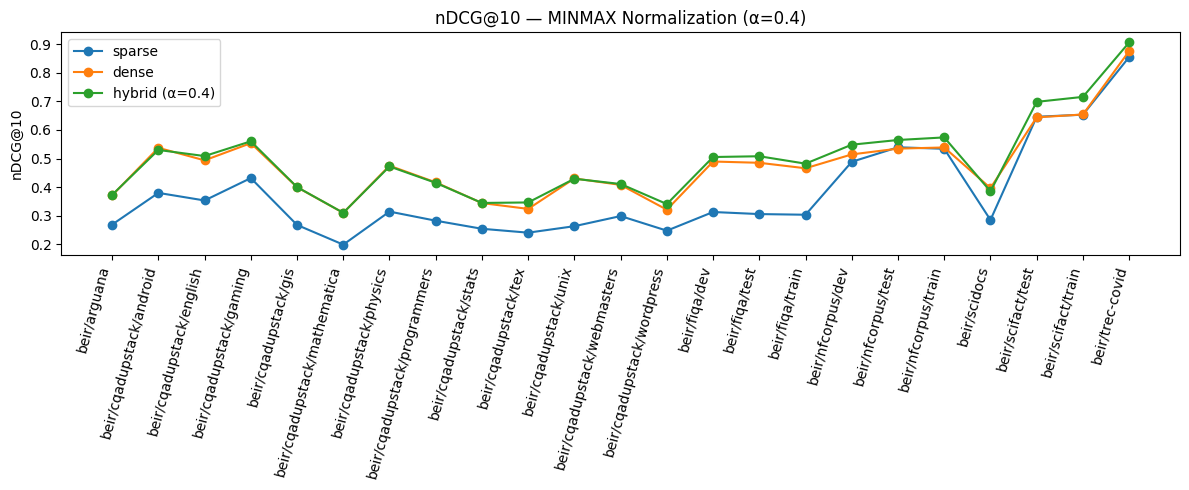

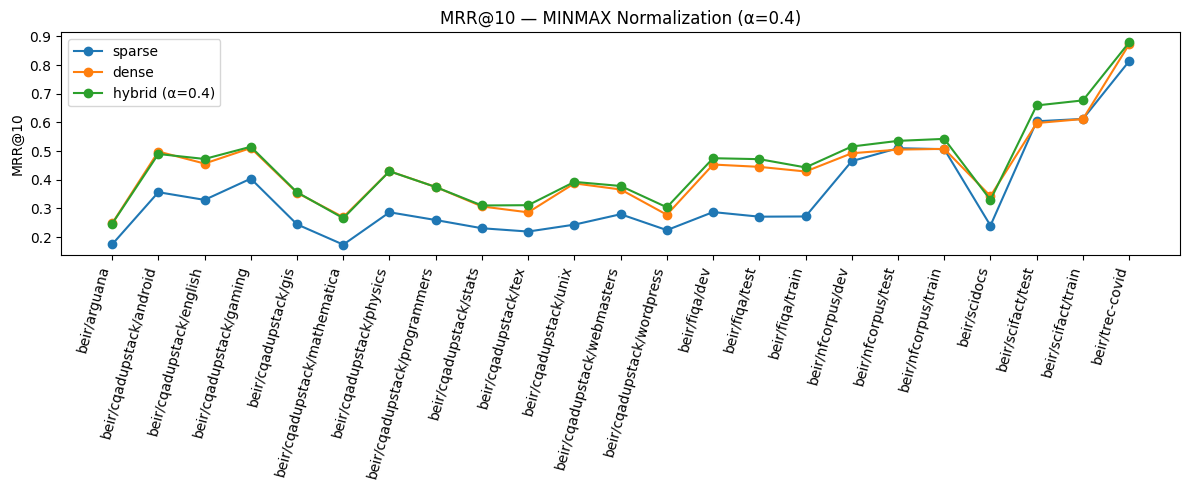

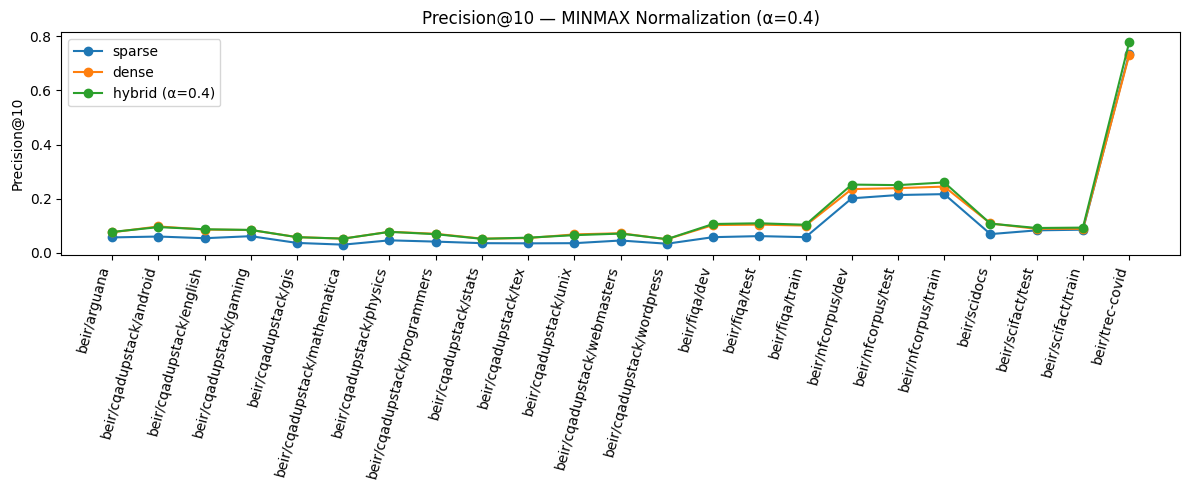

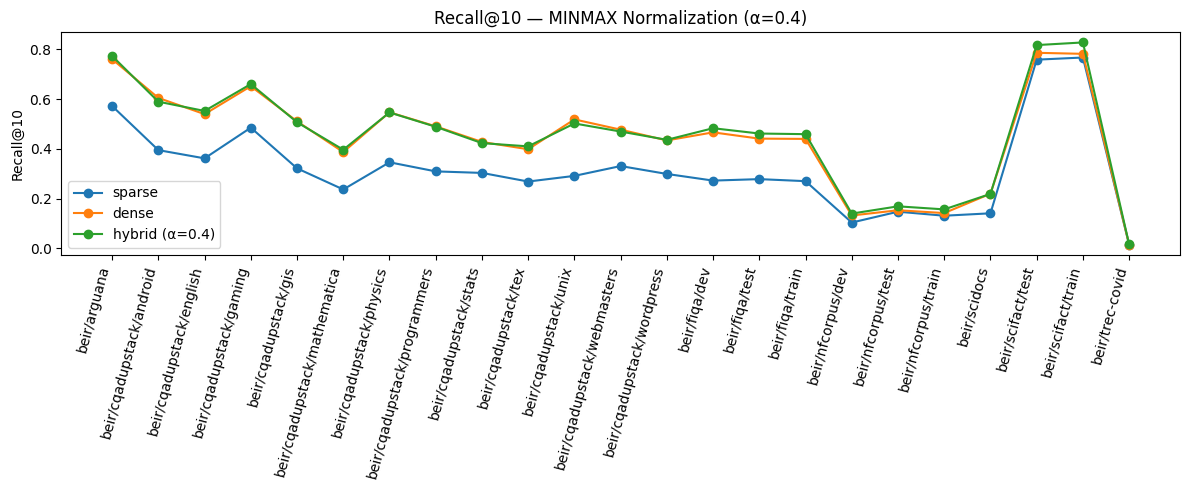

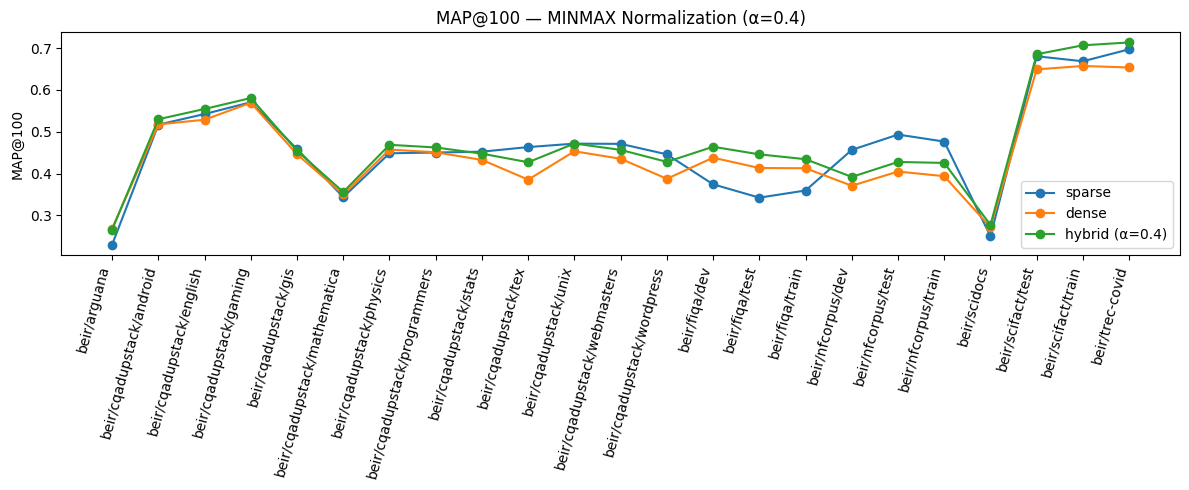

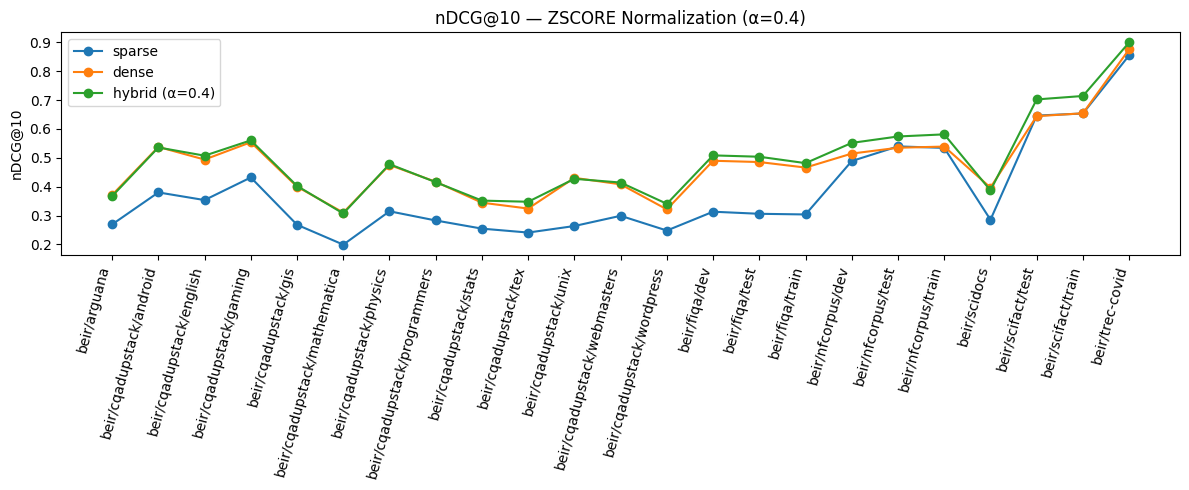

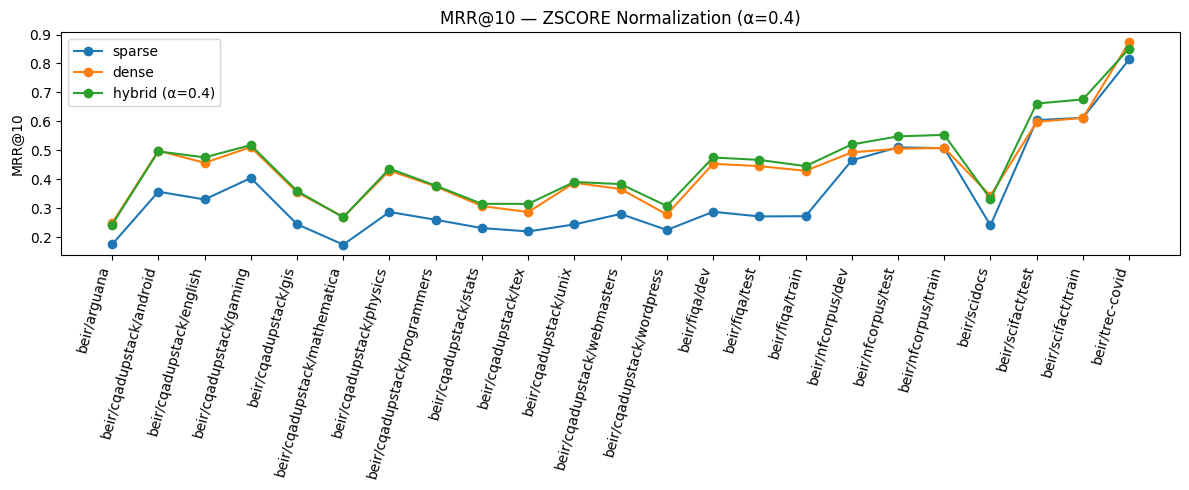

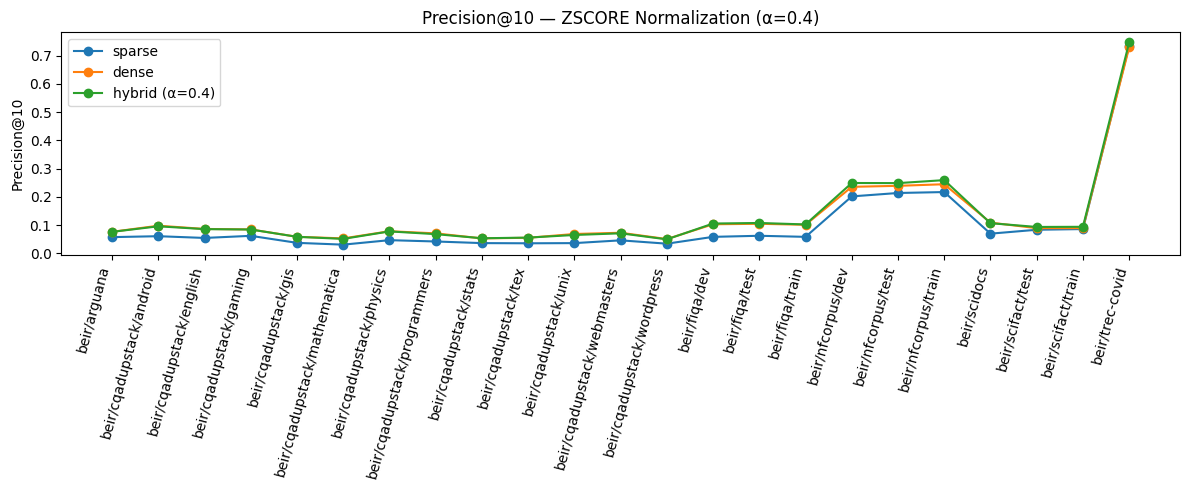

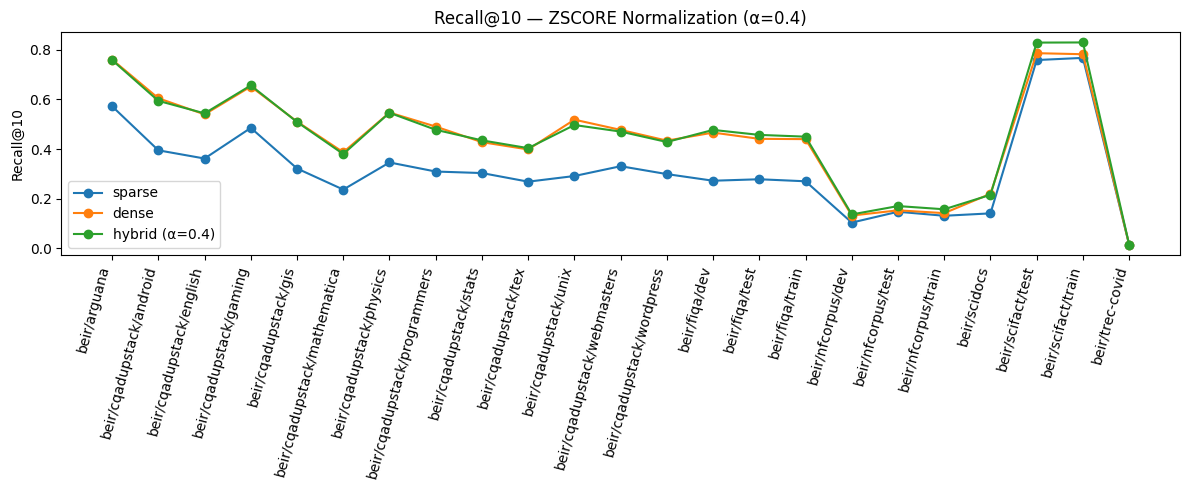

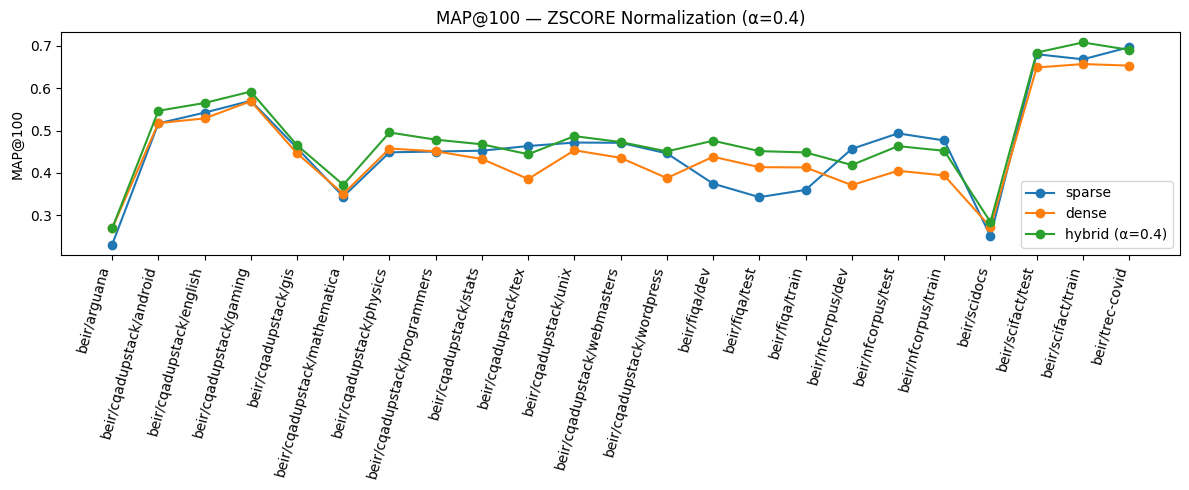

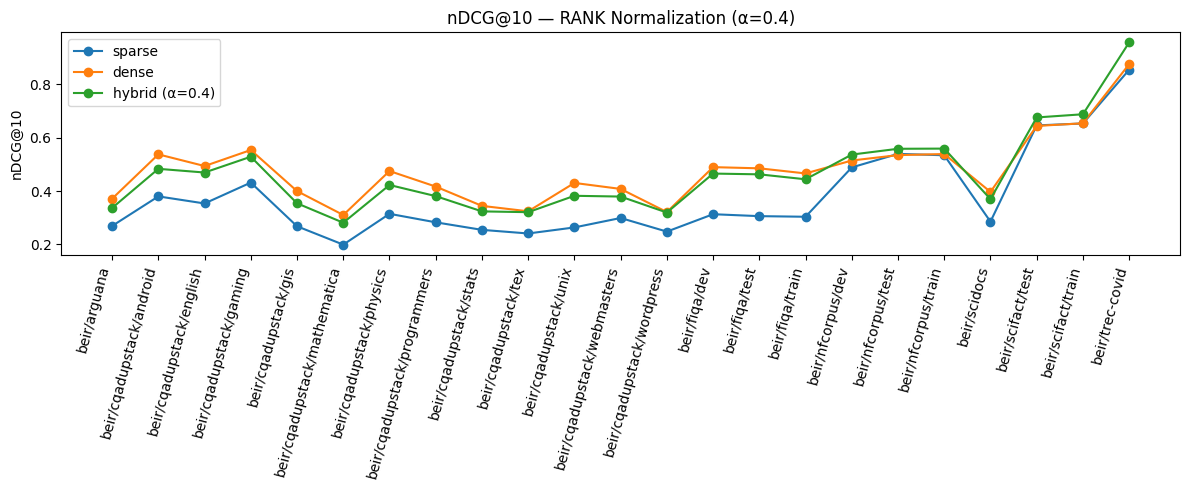

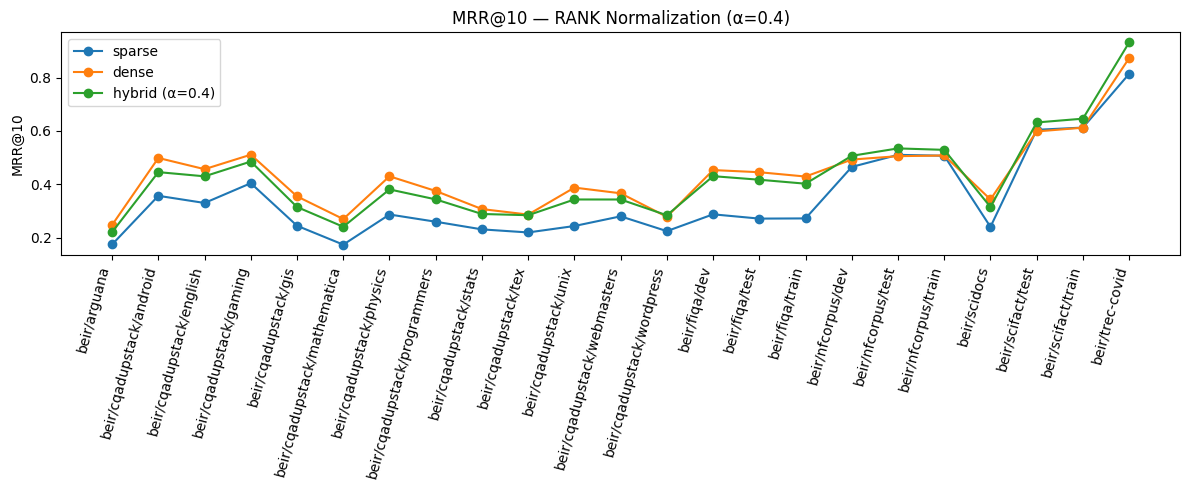

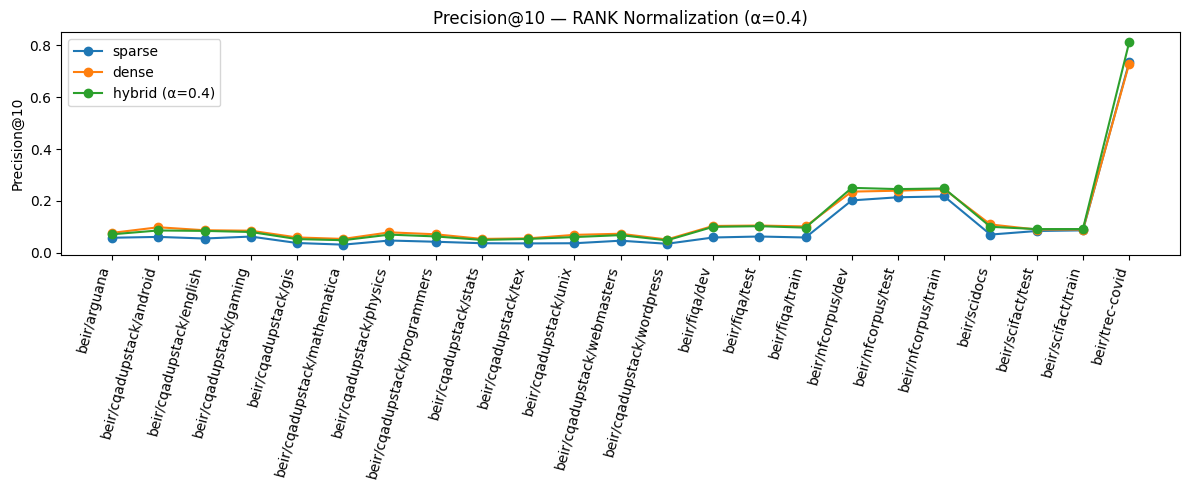

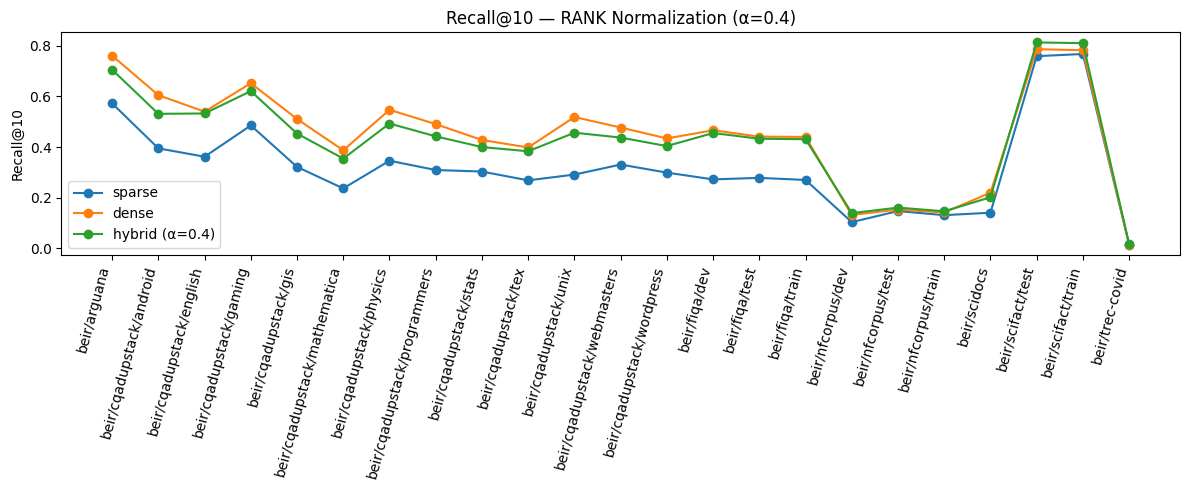

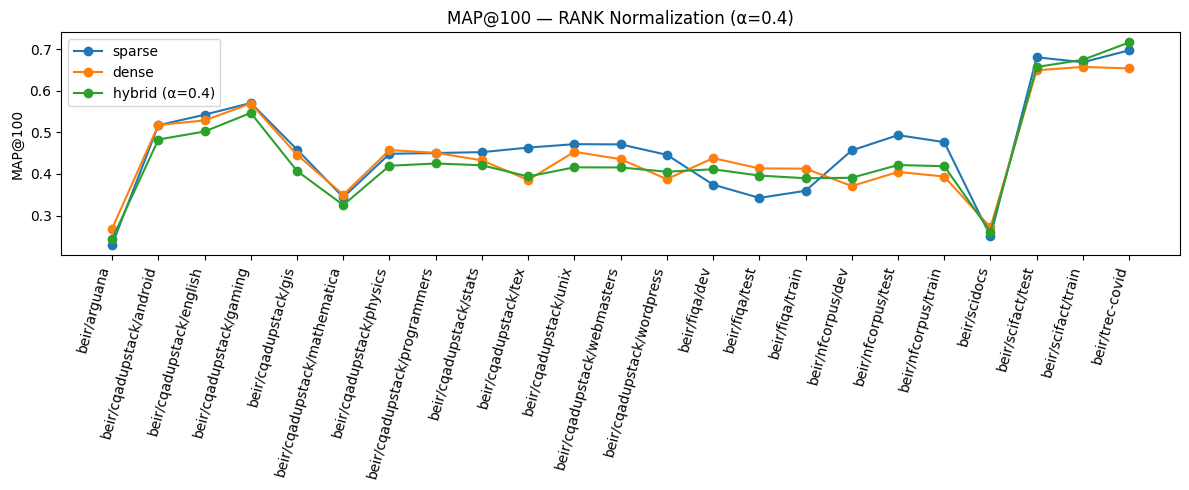

In [7]:
# ======================================================
# 📊 CELL 2 — Line Plots (Sparse vs Dense vs Hybrid α=0.4)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = ["nDCG@10","MRR@10","Precision@10","Recall@10","MAP@100"]
norms = ["minmax","zscore","rank"]

for norm in norms:
    for metric in metrics:
        plt.figure(figsize=(12,5))

        df_hybrid = df_final[(df_final["norm"]==norm) & (df_final["model"]=="hybrid")]
        df_sparse = df_final[(df_final["norm"]=="none") & (df_final["model"]=="sparse")]
        df_dense  = df_final[(df_final["norm"]=="none") & (df_final["model"]=="dense")]

        datasets_sorted = sorted(df_hybrid["dataset"].unique())
        x = np.arange(len(datasets_sorted))

        plt.plot(x, df_sparse.set_index("dataset").reindex(datasets_sorted)[metric],
                 marker="o", label="sparse")

        plt.plot(x, df_dense.set_index("dataset").reindex(datasets_sorted)[metric],
                 marker="o", label="dense")

        plt.plot(x, df_hybrid.set_index("dataset").reindex(datasets_sorted)[metric],
                 marker="o", label="hybrid (α=0.4)")

        plt.xticks(x, datasets_sorted, rotation=75, ha="right")
        plt.title(f"{metric} — {norm.upper()} Normalization (α=0.4)")
        plt.ylabel(metric)
        plt.legend()
        plt.tight_layout()
        plt.show()


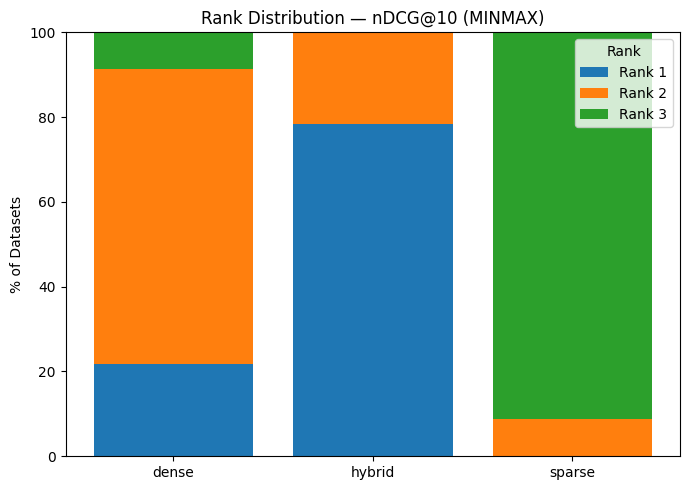

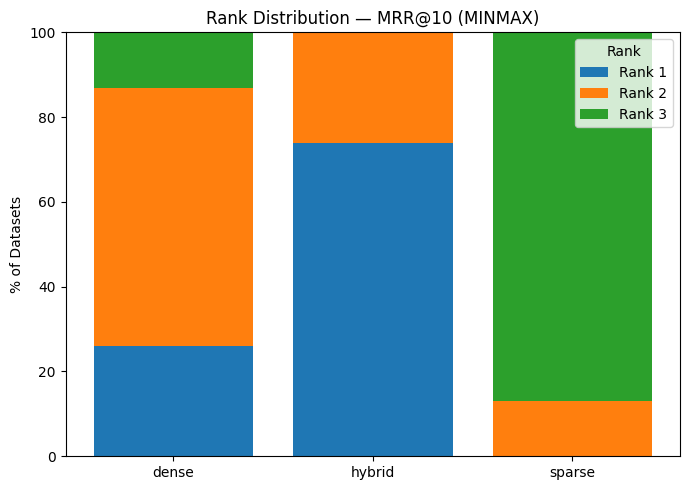

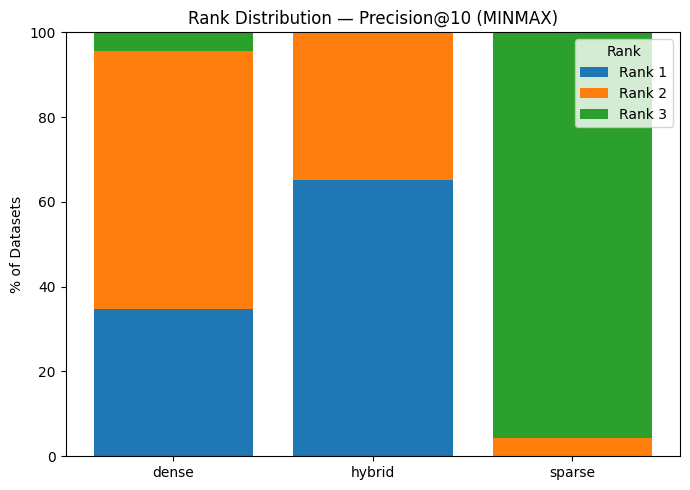

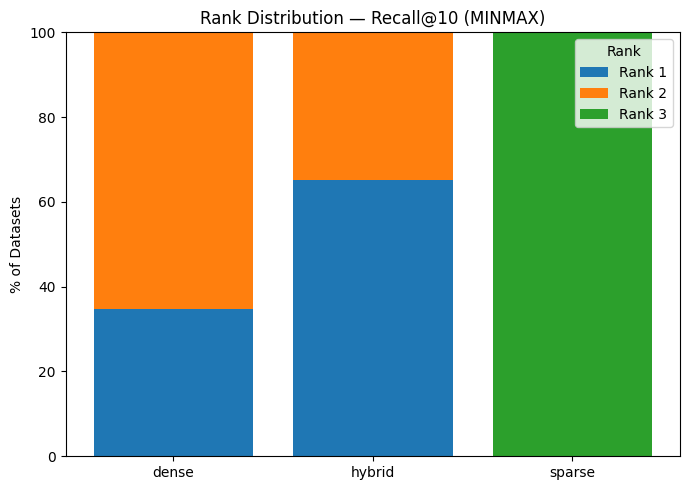

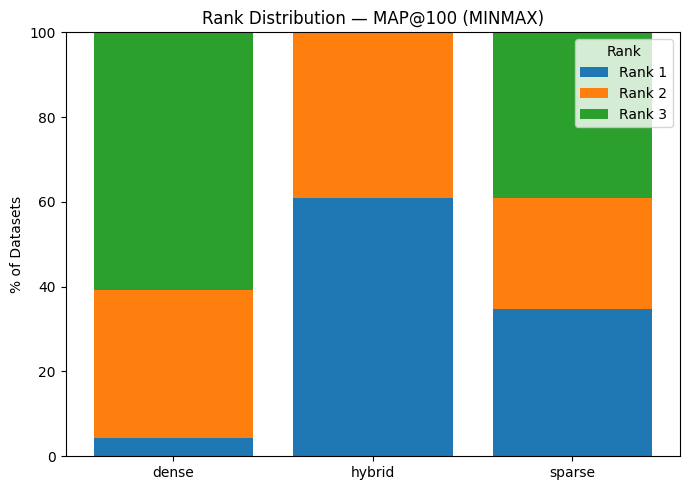

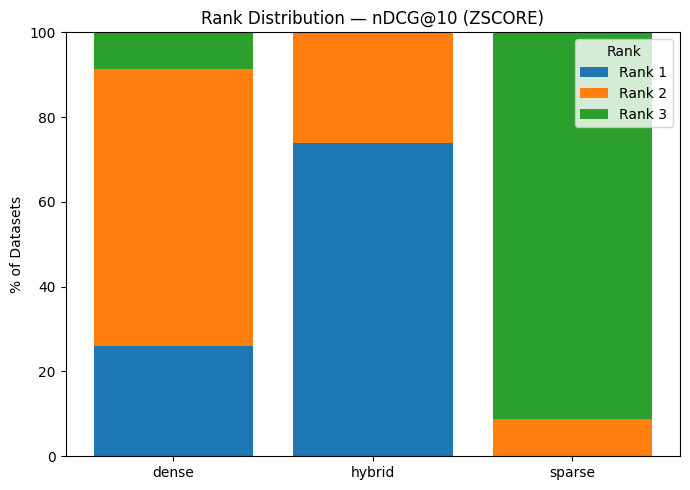

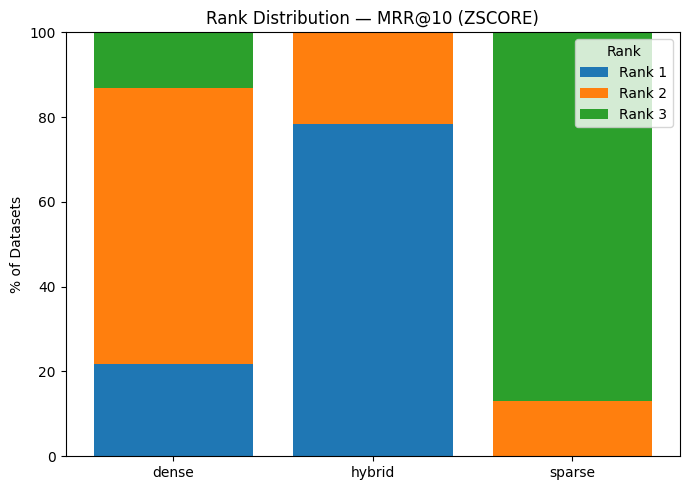

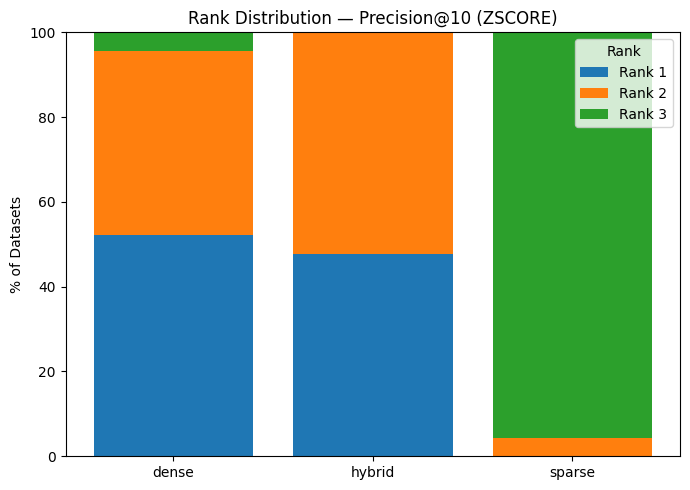

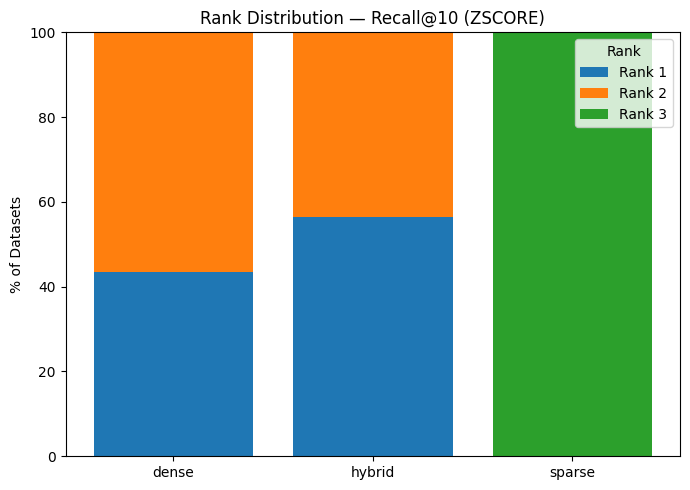

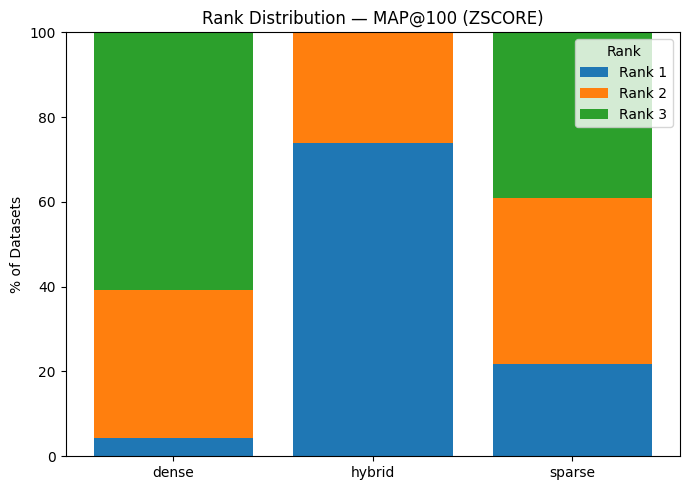

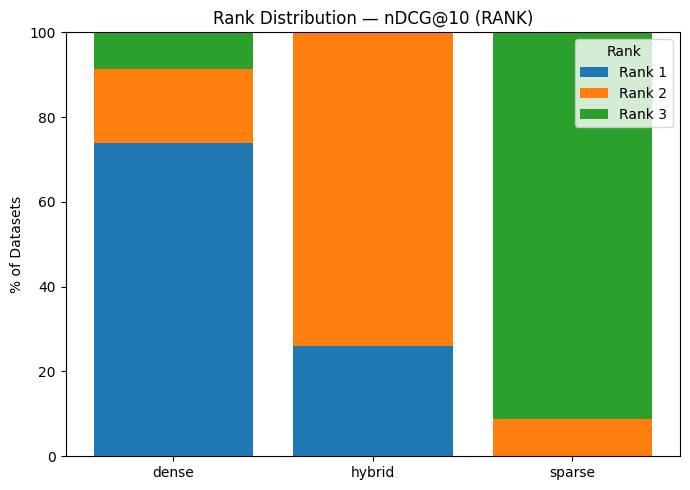

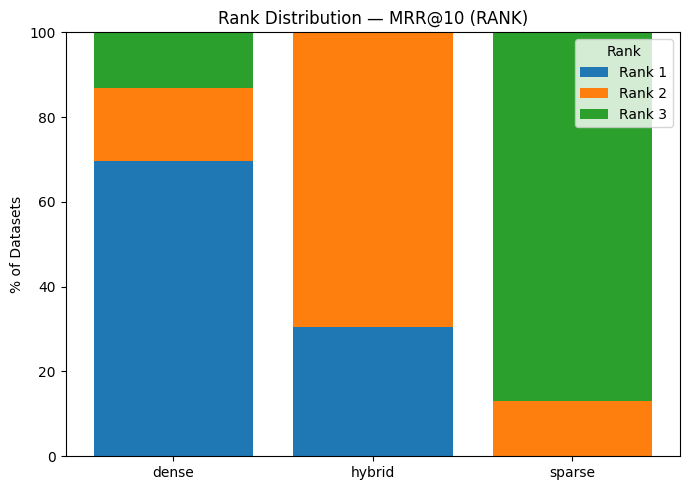

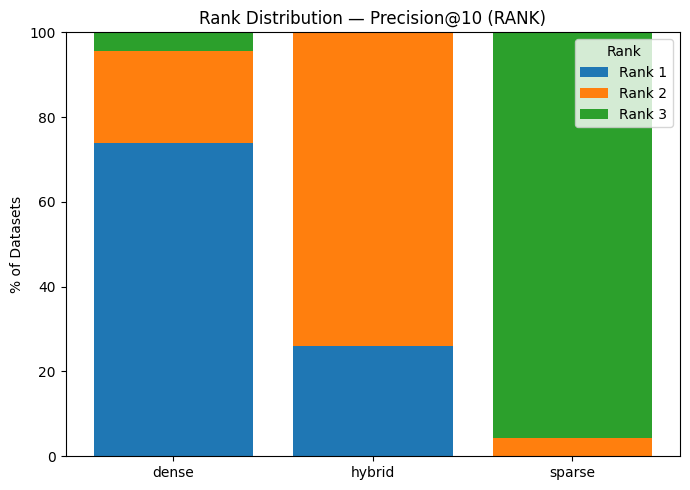

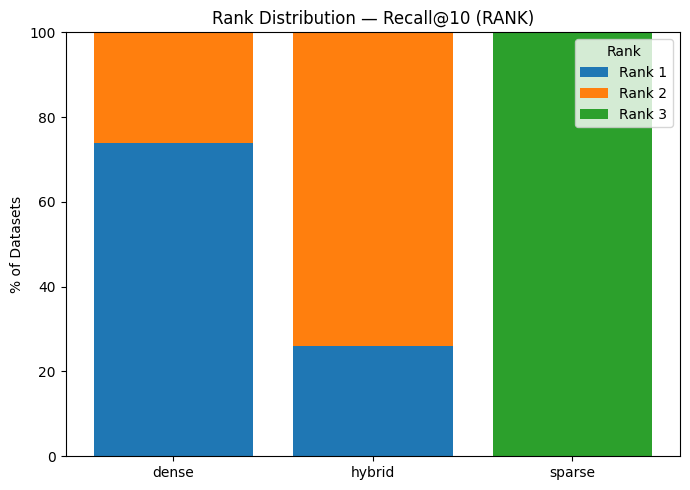

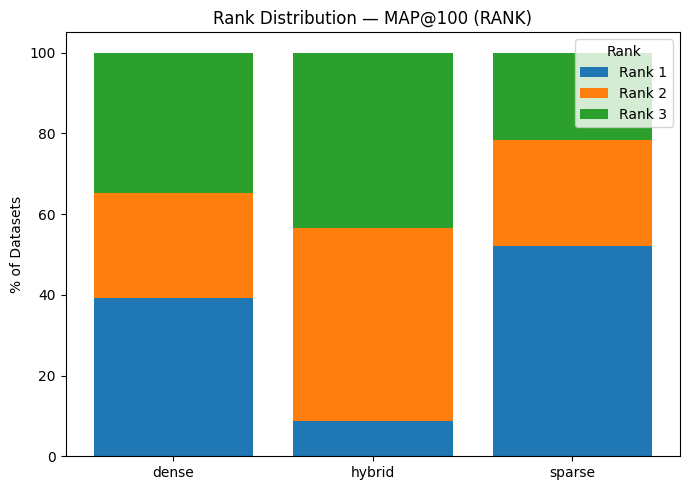

In [8]:
# ======================================================
# 📈 CELL 3 — Ranking Percentage Visualization (UPDATED)
# ======================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

summary_rows = []

for norm in ["minmax","zscore","rank"]:
    for metric in ["nDCG@10","MRR@10","Precision@10","Recall@10","MAP@100"]:

        df_hybrid = df_final[(df_final["norm"] == norm) & (df_final["model"] == "hybrid")]
        df_sparse = df_final[(df_final["norm"] == "none") & (df_final["model"] == "sparse")]
        df_dense  = df_final[(df_final["norm"] == "none") & (df_final["model"] == "dense")]

        combined = pd.concat([df_sparse, df_dense, df_hybrid], ignore_index=True)

        for dataset, group in combined.groupby("dataset"):
            g = group.copy()
            g["rank"] = g[metric].rank(ascending=False, method="min")

            for _, r in g.iterrows():
                summary_rows.append({
                    "norm": norm,
                    "metric": metric,
                    "dataset": dataset,
                    "model": r["model"],
                    "rank": int(r["rank"])
                })

rank_df = pd.DataFrame(summary_rows)

rank_summary = (
    rank_df.groupby(["norm","metric","model","rank"], as_index=False)
           .size()
           .rename(columns={"size":"count"})
)

rank_summary["percentage"] = (
    rank_summary.groupby(["norm","metric","model"])["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

for norm in ["minmax","zscore","rank"]:
    for metric in ["nDCG@10","MRR@10","Precision@10","Recall@10","MAP@100"]:

        sub = rank_summary[(rank_summary["norm"]==norm) &
                           (rank_summary["metric"]==metric)]
        pivot = sub.pivot(index="model", columns="rank", values="percentage").fillna(0)
        pivot = pivot.reindex(columns=[1,2,3])

        plt.figure(figsize=(7,5))
        bottom=np.zeros(len(pivot))

        for r in [1,2,3]:
            plt.bar(pivot.index, pivot[r], bottom=bottom, label=f"Rank {r}")
            bottom += pivot[r].values

        plt.title(f"Rank Distribution — {metric} ({norm.upper()})")
        plt.ylabel("% of Datasets")
        plt.legend(title="Rank")
        plt.tight_layout()
        plt.show()
